CAF Analysis Script
===========================
Author: Zae Moore (Syracuse University)
Last modified: 12-Dec-2025

Description:
This script analyzes MiniRun 6 flat CAF files. Looking at the purity and efficiency for certain cuts

Packages (run first to save time when running full script)

In [136]:
import uproot
import pandas as pd
import numpy as np
import awkward as ak
import matplotlib
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import os
import math
import csv
import math
import seaborn as sns
import sympy as smp
import sympy.stats
from scipy import stats,signal,ndimage,special,fft
from scipy.optimize import curve_fit
from scipy.integrate import quad
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.patches as mpatches
from matplotlib import colors
from sklearn.datasets import make_classification
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

## Cut Definitions and Functions

In [137]:
def truth_cuts(pdg, p, mode):
    """
    Truth level cuts
    Checks that the truth event is a CC2p0pi1mu event
    """
    nprotons = np.count_nonzero(pdg == 2212)
    nmuons = np.count_nonzero(pdg == 13) + np.count_nonzero(pdg == -13)
    npions = np.count_nonzero(pdg == 111) + np.count_nonzero(pdg == 211) + np.count_nonzero(pdg == -211) 

    #CC1mu2p
    if nprotons == 2 and nmuons == 1 and npions == 0: #and mode == 10: #2p2h
        return 1
    else:
        return 0
    
def reco_cuts(pdg, p, x_end, y_end, z_end, minerva_track_end_z):
    """
    Reco level cuts
    Cuts at the reco level
    - Counts 2 protons, 1 muon, and 0 pions
    - Cuts on proton momentum > 0.3 GeV/c
    - Requires proton to be contained in the TPC
    - Cuts on muon momentum > 0.3 GeV/c
    - Requires muon to punch out the back of minerva
    """
    nprotons = 0
    nmuons = 0
    npions = 0
    
    for part in range(len(pdg)):
        if pdg[part] == 2212: #and p[part] > 0.3: 
            if is_contained(x_end[part], y_end[part], z_end[part]):
                nprotons += 1
        if pdg[part] == 13 or pdg[part] == -13:
            #if p[part] >= 0.3: #and minerva_track_end_z[part] > 62.0:
            if minerva_track_end_z[part] > 62.0:
                nmuons += 1
        if pdg[part] == 111 or pdg[part] == 211 or pdg[part] == -211:
            npions += 1

    if nprotons == 2 and nmuons == 1 and npions == 0: #and len(pdg) == 3:
        return 1
    else:
        return 0
    
    
def mag(x):
    return np.sqrt(np.sum(i ** 2 for i in x))

def is_contained(x, y, z):
    tpc_dist = 8.0 #distance from the tpc walls for containment cuts
    xbound = 63.931
    ybound = 62.076
    zbound = 64.3163

    cont = False

    if abs(x) < xbound - tpc_dist and abs(y) < ybound - tpc_dist and abs(z) < zbound - tpc_dist:
        cont = True

    return cont

def theta(track1, track2):
    cos = np.dot(track1, track2) / (mag(track1) * mag(track2))
    cos = np.clip(cos, -1, 1)
    #p_theta = np.arccos(cos)
    return cos

## Load CAF root file

File contains events that have passed the reconstruction cuts, and were identified as potential signal events

In [138]:
tracks = uproot.open("/nashome/z/zaemoore/2x2_CAF/purity_efficiency/2p2h_purity_eff_m6.5_1.1.root")
tracks["CafTree"].show()
tracks["CafTree"].keys()

branches = tracks["CafTree"].arrays()[0]
file_index = branches['file_index']
#print(np.unique(file_index))

name                 | typename                 | interpretation                
---------------------+--------------------------+-------------------------------
reco_energy          | std::vector<double>      | AsJagged(AsDtype('>f8'), he...
reco_p_x             | std::vector<double>      | AsJagged(AsDtype('>f8'), he...
reco_p_y             | std::vector<double>      | AsJagged(AsDtype('>f8'), he...
reco_p_z             | std::vector<double>      | AsJagged(AsDtype('>f8'), he...
reco_p_mag           | std::vector<double>      | AsJagged(AsDtype('>f8'), he...
reco_length          | std::vector<double>      | AsJagged(AsDtype('>f8'), he...
reco_angle           | std::vector<double>      | AsJagged(AsDtype('>f8'), he...
reco_angle_rot       | std::vector<double>      | AsJagged(AsDtype('>f8'), he...
reco_angle_incl      | std::vector<double>      | AsJagged(AsDtype('>f8'), he...
reco_angle_x         | std::vector<double>      | AsJagged(AsDtype('>f8'), he...
reco_angle_y         | std::

## Save file information <br>

Calculate Purity <br>
Purity = Number of True CC1mu2p0pi Events that pass all cuts/Number of events that pass all cuts <br>
Calculate Efficiency <br>
Efficiency = Number of true signal events that pass all cuts/Number of true signal events <br> <br>

Signal means the reconstructed event is the "signal" we are looking for (reco passes the cuts) <br>
True means the truth level event is what we are looking for (truth passes the cuts)

In [139]:
#Arrays to save information on whether each event passes reco and true cuts, and the type of event it is
true_signal_event = []
true_event = []
signal_event = []
mode_event = []

#Reco momentum and proton angle information
leading_p_p = []
recoil_p_p = []
muon_p = []
theta_pp = []
candidate_files = []

#Reco and true proton momentum and neutrino energy
true_proton_p = []
reco_proton_p = []
true_muon_p = []
true_nu_momentum = []

#Proton ID accuracy
true_pid = []
reco_pid = []

#Proton true and reco momentum for 2D histogram
hist_proton_truep = []
hist_proton_recop = []

#Genie weights
genweight_all = []

#Loop through each file index
for file_idx in np.unique(file_index):
    true_energy = branches['true_energy'][file_index == file_idx]
    true_p_x = branches['true_p_x'][file_index == file_idx]
    true_p_y = branches['true_p_y'][file_index == file_idx]
    true_p_z = branches['true_p_z'][file_index == file_idx]
    true_p_mag = branches['true_p_mag'][file_index == file_idx]
    true_length = branches['true_length'][file_index == file_idx]
    true_angle = branches['true_angle'][file_index == file_idx]
    true_angle_rot = branches['true_angle_rot'][file_index == file_idx]
    true_angle_incl = branches['true_angle_incl'][file_index == file_idx]
    true_angle_x = branches['true_angle_x'][file_index == file_idx]
    true_angle_y = branches['true_angle_y'][file_index == file_idx]
    true_angle_z = branches['true_angle_z'][file_index == file_idx]
    true_vtx_x = branches['true_vtx_x'][file_index == file_idx]
    true_vtx_y = branches['true_vtx_y'][file_index == file_idx]
    true_vtx_z = branches['true_vtx_z'][file_index == file_idx]
    true_track_start_x = branches['true_track_start_x'][file_index == file_idx]
    true_track_start_y = branches['true_track_start_y'][file_index == file_idx]
    true_track_start_z = branches['true_track_start_z'][file_index == file_idx]
    true_track_end_x = branches['true_track_end_x'][file_index == file_idx]
    true_track_end_y = branches['true_track_end_y'][file_index == file_idx]
    true_track_end_z = branches['true_track_end_z'][file_index == file_idx]
    true_pdg = branches['true_pdg'][file_index == file_idx]
    true_nproton = branches['true_nproton'][file_index == file_idx]
    mode = branches['mode'][file_index == file_idx]
    nu_momentum_x = branches['nu_momentum_x'][file_index == file_idx]
    nu_momentum_y = branches['nu_momentum_y'][file_index == file_idx]
    nu_momentum_z = branches['nu_momentum_z'][file_index == file_idx]

    minerva_track_E = branches['minerva_track_E'][file_index == file_idx]
    minerva_track_dir_x = branches['minerva_track_dir_x'][file_index == file_idx]
    minerva_track_dir_y = branches['minerva_track_dir_y'][file_index == file_idx]
    minerva_track_dir_z = branches['minerva_track_dir_z'][file_index == file_idx]
    minerva_track_enddir_x = branches['minerva_track_enddir_x'][file_index == file_idx]
    minerva_track_enddir_y = branches['minerva_track_enddir_y'][file_index == file_idx]
    minerva_track_enddir_z = branches['minerva_track_enddir_z'][file_index == file_idx]
    minerva_track_start_x = branches['minerva_track_start_x'][file_index == file_idx]
    minerva_track_start_y = branches['minerva_track_start_y'][file_index == file_idx]
    minerva_track_start_z = branches['minerva_track_start_z'][file_index == file_idx]
    minerva_track_end_x = branches['minerva_track_end_x'][file_index == file_idx]
    minerva_track_end_y = branches['minerva_track_end_y'][file_index == file_idx]
    minerva_track_end_z = branches['minerva_track_end_z'][file_index == file_idx]
    minerva_track_len_cm = branches['minerva_track_len_cm'][file_index == file_idx]

    reco_energy = branches['reco_energy'][file_index == file_idx]
    reco_p_x = branches['reco_p_x'][file_index == file_idx]
    reco_p_y = branches['reco_p_y'][file_index == file_idx]
    reco_p_z = branches['reco_p_z'][file_index == file_idx]
    reco_p_mag = branches['reco_p_mag'][file_index == file_idx]
    reco_length = branches['reco_length'][file_index == file_idx]
    reco_angle = branches['reco_angle'][file_index == file_idx]
    reco_angle_rot = branches['reco_angle_rot'][file_index == file_idx]
    reco_angle_incl = branches['reco_angle_incl'][file_index == file_idx]
    reco_angle_x = branches['reco_angle_x'][file_index == file_idx]
    reco_angle_y = branches['reco_angle_y'][file_index == file_idx]
    reco_angly_z = branches['reco_angle_z'][file_index == file_idx]
    reco_vtx_x = branches['reco_vtx_x'][file_index == file_idx]
    reco_vtx_y = branches['reco_vtx_y'][file_index == file_idx]
    reco_vtx_z = branches['reco_vtx_z'][file_index == file_idx]
    reco_track_start_x = branches['reco_track_start_x'][file_index == file_idx]
    reco_track_start_y = branches['reco_track_start_y'][file_index == file_idx]
    reco_track_start_z = branches['reco_track_start_z'][file_index == file_idx]
    reco_track_end_x = branches['reco_track_end_x'][file_index == file_idx]
    reco_track_end_y = branches['reco_track_end_y'][file_index == file_idx]
    reco_track_end_z = branches['reco_track_end_z'][file_index == file_idx]
    reco_pdg = branches['reco_pdg'][file_index == file_idx]
    reco_enu_calo = branches['reco_enu_calo'][file_index == file_idx]

    reco_ixn_index = branches['reco_ixn_index'][file_index == file_idx]
    spill_index = branches['spill_index'][file_index == file_idx]
    event = branches['event'][file_index == file_idx]
    subrun = branches['subrun'][file_index == file_idx]
    caf_file_name = branches['caf_file_name'][file_index == file_idx]

    #Loop through each event in the file
    for ev in np.unique(event):

        reco_pdg_ev = reco_pdg[event == ev]
        true_pdg_ev = true_pdg[event == ev]

        xp_track = []
        yp_track = []
        zp_track = []

        #Do the reco event and matching truth event pass the cuts?
        reco_passes = reco_cuts(reco_pdg[event == ev], reco_p_mag[event == ev], reco_track_end_x[event == ev], 
                                reco_track_end_y[event == ev], reco_track_end_z[event == ev], minerva_track_end_z[event == ev])
        truth_passes = truth_cuts(true_pdg[event == ev], true_p_mag[event == ev], mode[event == ev][0])

        signal_event.append(reco_passes)
        true_event.append(truth_passes)
        mode_event.append(mode[event == ev][0])

        if reco_passes == 1 and truth_passes == 1:
            true_signal_event.append(1)
        else:
            true_signal_event.append(0)

        #Save proton and muon momentum information for plots
        proton_p_reco = reco_p_mag[event == ev][reco_pdg[event == ev] == 2212]
        proton_p_truth = true_p_mag[event == ev][true_pdg[event == ev] == 2212]
        muon_p_reco = reco_p_mag[event == ev][reco_pdg[event == ev] == 13]
        muon_p_truth = true_p_mag[event == ev][true_pdg[event == ev] == 13]

        
        nu_momentum = mag((nu_momentum_x[event == ev][0], nu_momentum_y[event == ev][0], nu_momentum_z[event == ev][0]))

        # Loop through particles
        for part in range(len(true_pdg_ev)):
            true_pid.append(true_pdg_ev[part])
            reco_pid.append(reco_pdg_ev[part])
            if true_pdg_ev[part] == 2212:
                xp_track.append(true_track_end_x[event == ev][part] - true_track_start_x[event == ev][part])
                yp_track.append(true_track_end_y[event == ev][part] - true_track_start_y[event == ev][part])
                zp_track.append(true_track_end_z[event == ev][part] - true_track_start_z[event == ev][part])
                if reco_pdg_ev[part] == 2212:
                    #Save proton momentum info for momentum 2d histogram only if the particle is both true and reco proton
                    hist_proton_truep.append(true_p_mag[event == ev][part])
                    hist_proton_recop.append(reco_p_mag[event == ev][part])

        if len(zp_track) == 2:
            #Compare angles for every combination of truth protons in events with >=2 protons
            for i in range(len(zp_track) - 1):
                for j in range(i+1, len(zp_track)):
                    track1 = [xp_track[i], yp_track[i], zp_track[i]]
                    track2 = [xp_track[j], yp_track[j], zp_track[j]]
                    angle = theta(track1, track2)
                    if angle <= -0.95:
                        candidate_files.append(file_idx)
                    theta_pp.append(angle)
        else:
            theta_pp.append(2)

        reco_proton_p.extend(proton_p_reco)
        true_proton_p.extend(proton_p_truth)
        true_muon_p.extend(muon_p_truth)

        #Find max (lead) and min (recoil) protons
        #Some events may be true CC2p1mu0pi, but the reconstruction may not see any protons
        #We need to account for these events that have no proton momentum
        if len(proton_p_truth) == 0:
            leading_p_p.append(0)
            recoil_p_p.append(0)
        else:
            leading_p_p.append(max(proton_p_truth))
            recoil_p_p.append(min(proton_p_truth))

        if len(true_muon_p) == 0:
            muon_p.append(0)
        else:
            muon_p.append((true_muon_p[0]))

        true_nu_momentum.append(nu_momentum)
        
        #Save angle between protons for plots FOR LATER

#In this code, signal means event that passes the reco cuts (detector would identify it as a 2p2h event)
#True signal event means an event that passes the reco cuts and is a 2p2h event at truth level
#True event is a 2p2h event at truth level
num_true_signal = sum(true_signal_event) #Number of 2p2h events that pass the cut
num_background = sum(signal_event) - num_true_signal #Number of background events that pass the cut

print("Number of signal events", num_true_signal)

print("Number of background events", num_background)

purity = sum(true_signal_event)/sum(signal_event)
print("Purity measurement: ", purity)

efficiency = sum(true_signal_event)/sum(true_event)
print("Efficiency measurement: ", efficiency)

/tmp/ipykernel_518305/538908095.py:48: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  return np.sqrt(np.sum(i ** 2 for i in x))


Number of signal events 110
Number of background events 48
Purity measurement:  0.6962025316455697
Efficiency measurement:  0.6395348837209303


## Purity and efficiency vs. kinematic variables

/tmp/ipykernel_518305/4285327901.py:87: RuntimeWarning: divide by zero encountered in scalar divide
  stat_error_lpp.append(1/np.sqrt(n_events))
/tmp/ipykernel_518305/4285327901.py:110: RuntimeWarning: divide by zero encountered in scalar divide
  stat_error_rpp.append(1/np.sqrt(n_events))
/tmp/ipykernel_518305/4285327901.py:133: RuntimeWarning: divide by zero encountered in scalar divide
  stat_error_mu.append(1/np.sqrt(n_events))
/tmp/ipykernel_518305/4285327901.py:156: RuntimeWarning: divide by zero encountered in scalar divide
  stat_error_nu.append(1/np.sqrt(n_events))


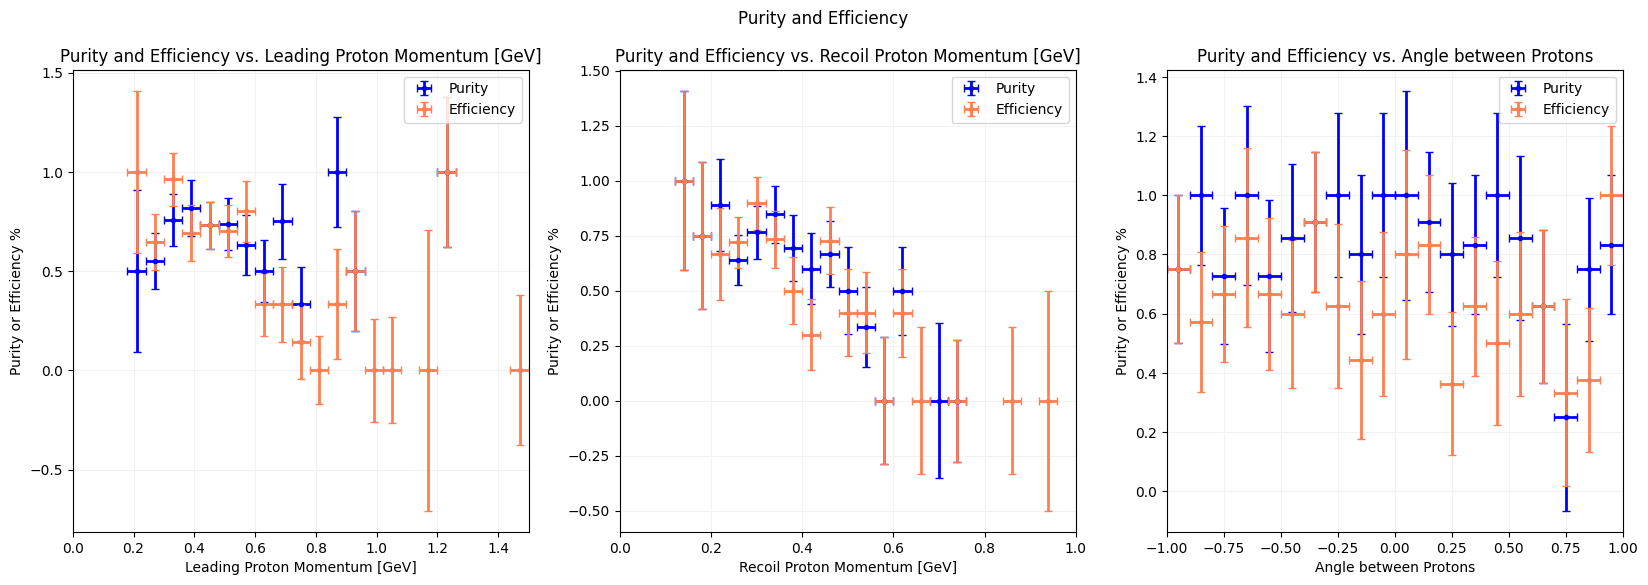

In [140]:
data = {'signal': signal_event, 'true': true_event, 'true and signal': true_signal_event, 'leading proton p': leading_p_p, 'recoil proton p': recoil_p_p, 'muon p': muon_p, 'nu momentum': true_nu_momentum, 'theta pp': theta_pp}
df = pd.DataFrame(data=data)
# All the independent variables are truth rn (momentum, angle)

#Save purity and efficiency values
purity_vals_lpp = []
purity_vals_rpp = []
purity_vals_mu = []
purity_vals_nu = []
purity_vals_theta = []
eff_vals_lpp = []
eff_vals_rpp = []
eff_vals_mu = []
eff_vals_nu = []
eff_vals_theta = []
stat_error_lpp = []
stat_error_rpp = []
stat_error_mu = []
stat_error_nu = []
stat_error_theta = []

#For significance plot
signal_lpp = []
signal_rpp = []
signal_mu = []
signal_nu = []
signal_theta = []
background_lpp = []
background_rpp = []
background_mu = []
background_nu = []
background_theta = []

#Leading proton momentum binning
nbins_lpp = 25
hist_lpp, bin_edges_lpp = np.histogram(leading_p_p, bins=nbins_lpp, range=(0,1.5)) #Create bins based on leading proton momentum
bin_centers_lpp = (bin_edges_lpp[:-1] + bin_edges_lpp[1:])/2
bin_width_lpp = (bin_edges_lpp[-1] + bin_edges_lpp[0])/nbins_lpp
labels_lpp = np.arange(0, nbins_lpp) #Label each bin numerically for leading proton momentum

df['bin lpp'] = pd.cut(df['leading proton p'], bins=bin_edges_lpp, labels=labels_lpp) #Create a column in df defining the number bin each event is in based on leading proton momentum

#Recoil proton momentum binning
nbins_rpp = 25
hist_rpp, bin_edges_rpp = np.histogram(recoil_p_p, bins=nbins_rpp, range=(0,1.0)) #Create bins based on recoil proton momentum
bin_centers_rpp = (bin_edges_rpp[:-1] + bin_edges_rpp[1:])/2
bin_width_rpp = (bin_edges_rpp[-1] + bin_edges_rpp[0])/nbins_rpp
labels_rpp = np.arange(0, nbins_rpp) #Label each bin numerically for recoil proton momentum

df['bin rpp'] = pd.cut(df['recoil proton p'], bins=bin_edges_rpp, labels=labels_rpp) #Create a column in df defining the number bin each event is in based on recoil proton momentum

#Muon momentum binning
nbins_mu = 25
hist_mu, bin_edges_mu = np.histogram(muon_p, bins=nbins_mu, range=(0,1.0)) #Create bins based on recoil proton momentum
bin_centers_mu = (bin_edges_mu[:-1] + bin_edges_mu[1:])/2
bin_width_mu = (bin_edges_mu[-1] + bin_edges_mu[0])/nbins_mu
labels_mu = np.arange(0, nbins_mu) #Label each bin numerically for recoil proton momentum

df['bin mu'] = pd.cut(df['muon p'], bins=bin_edges_mu, labels=labels_mu) #Create a column in df defining the number bin each event is in based on recoil proton momentum

#Neutrino energy binning
nbins_nu = 25
hist_nu, bin_edges_nu = np.histogram(true_nu_momentum, bins=nbins_nu, range=(0,20)) #Create bins based on true neutrino energy
bin_centers_nu = (bin_edges_nu[:-1] + bin_edges_nu[1:])/2
bin_width_nu = (bin_edges_nu[-1] + bin_edges_nu[0])/nbins_nu
labels_nu = np.arange(0, nbins_nu) #Label each bin numerically for true neutrino energy

df['bin nu'] = pd.cut(df['nu momentum'], bins=bin_edges_nu, labels=labels_nu) #Create a column in df defining the number bin each event is in based on true neutrino energy

#Theta pp binning
nbins_theta = 20
hist_theta, bin_edges_theta = np.histogram(theta_pp, bins=nbins_theta, range=(-1, 1)) #Create bins based on theta pp
bin_centers_theta = (bin_edges_theta[:-1] + bin_edges_theta[1:])/2
bin_width_theta = (bin_edges_theta[-1] + bin_edges_theta[0])/nbins_theta
labels_theta = np.arange(0, nbins_theta) #Label each bin numerically for theta pp

df['bin theta'] = pd.cut(df['theta pp'], bins=bin_edges_theta, labels=labels_theta) #Create a column in df defining the number bin each event is in based on theta pp

# Loop through each leading proton momentum bin and calculate purity & efficiency
for i in labels_lpp:
    df_bin = df[(df['bin lpp'] == i)]

    signal_bin = np.array(df_bin['signal'])
    true_signal_bin = np.array(df_bin['true and signal'])
    true_bin = np.array(df_bin['true'])
    n_events = len(signal_bin)
    stat_error_lpp.append(1/np.sqrt(n_events))

    signal_lpp.append(sum(signal_bin))
    background_lpp.append(sum(signal_bin) - sum(true_signal_bin))

    if sum(signal_bin) == 0:
        purity_vals_lpp.append(np.nan)
    else:
        purity_vals_lpp.append(sum(true_signal_bin)/sum(signal_bin))
    
    if sum(true_bin) == 0:
        eff_vals_lpp.append(np.nan)
    else:
        eff_vals_lpp.append(sum(true_signal_bin)/sum(true_bin))

# Loop through each recoil proton momentum bin and calculate purity & efficiency
for i in labels_rpp:
    df_bin = df[(df['bin rpp'] == i)]

    signal_bin = np.array(df_bin['signal'])
    true_signal_bin = np.array(df_bin['true and signal'])
    true_bin = np.array(df_bin['true'])
    n_events = len(signal_bin)
    stat_error_rpp.append(1/np.sqrt(n_events))

    signal_rpp.append(sum(signal_bin))
    background_rpp.append(sum(signal_bin) - sum(true_signal_bin))

    if sum(signal_bin) == 0:
        purity_vals_rpp.append(np.nan)
    else:
        purity_vals_rpp.append(sum(true_signal_bin)/sum(signal_bin))

    if sum(true_bin) == 0:
        eff_vals_rpp.append(np.nan)
    else:
        eff_vals_rpp.append(sum(true_signal_bin)/sum(true_bin))

# Loop through each muon momentum bin and calculate purity and efficiency
for i in labels_mu:
    df_bin = df[(df['bin mu'] == i)]

    signal_bin = np.array(df_bin['signal'])
    true_signal_bin = np.array(df_bin['true and signal'])
    true_bin = np.array(df_bin['true'])
    n_events = len(signal_bin)
    stat_error_mu.append(1/np.sqrt(n_events))

    signal_mu.append(sum(signal_bin))
    background_mu.append(sum(signal_bin) - sum(true_signal_bin))

    if sum(signal_bin) == 0:
        purity_vals_mu.append(np.nan)
    else:
        purity_vals_mu.append(sum(true_signal_bin)/sum(signal_bin))

    if sum(true_bin) == 0:
        eff_vals_mu.append(np.nan)
    else:
        eff_vals_mu.append(sum(true_signal_bin)/sum(true_bin))

# Loop through each true neutrino energy bin and calculate purity and efficiency
for i in labels_nu:
    df_bin = df[(df['bin nu'] == i)]

    signal_bin = np.array(df_bin['signal'])
    true_signal_bin = np.array(df_bin['true and signal'])
    true_bin = np.array(df_bin['true'])
    n_events = len(signal_bin)
    stat_error_nu.append(1/np.sqrt(n_events))

    signal_nu.append(sum(signal_bin))
    background_nu.append(sum(signal_bin) - sum(true_signal_bin))

    if sum(signal_bin) == 0:
        purity_vals_nu.append(np.nan)
    else:
        purity_vals_nu.append(sum(true_signal_bin)/sum(signal_bin))

    if sum(true_bin) == 0:
        eff_vals_nu.append(np.nan)
    else:
        eff_vals_nu.append(sum(true_signal_bin)/sum(true_bin))

# Loop through each angle between proton bin and calculate purity and efficiency FOR LATER
for i in labels_theta:
    df_bin = df[(df['bin theta'] == i)]

    signal_bin = np.array(df_bin['signal'])
    true_signal_bin = np.array(df_bin['true and signal'])
    true_bin = np.array(df_bin['true'])
    n_events = len(signal_bin)
    stat_error_theta.append(1/np.sqrt(n_events))

    signal_theta.append(sum(signal_bin))
    background_theta.append(sum(signal_bin) - sum(true_signal_bin))

    if sum(signal_bin) == 0:
        purity_vals_theta.append(np.nan)
    else:
        purity_vals_theta.append(sum(true_signal_bin)/sum(signal_bin))

    if sum(true_bin) == 0:
        eff_vals_theta.append(np.nan)
    else:
        eff_vals_theta.append(sum(true_signal_bin)/sum(true_bin))

# Delete the last bin value because we are plotting each step from the leftmost bin edge
lpp_values = np.delete(bin_edges_lpp, nbins_lpp)
rpp_values = np.delete(bin_edges_rpp, nbins_rpp)
mu_values = np.delete(bin_edges_mu, nbins_mu)
nu_values = np.delete(bin_edges_nu, nbins_nu)
theta_values = np.delete(bin_edges_theta, nbins_theta)


#Purity and Efficiency Plots
fig, ax = plt.subplots(1, 3, figsize=(20,6))
fig.suptitle('Purity and Efficiency')
#Plot purity and efficiency vs. leading proton momentum
#ax[0,0].step(lpp_values, purity_vals_lpp, where='post', label='Purity', linewidth='2')
#ax[0,0].step(lpp_values, eff_vals_lpp, where='post', label='Efficiency', linewidth='2')
ax[0].errorbar(bin_centers_lpp, purity_vals_lpp, xerr=bin_width_lpp/2, yerr=stat_error_lpp, fmt='.', color='blue', label='Purity', elinewidth=2, capsize=3)
ax[0].errorbar(bin_centers_lpp, eff_vals_lpp, xerr=bin_width_lpp/2, yerr=stat_error_lpp, fmt='.', color='coral', label='Efficiency', elinewidth=2, capsize=3)
ax[0].set_xlabel('Leading Proton Momentum [GeV]')
ax[0].set_ylabel('Purity or Efficiency %')
ax[0].set_title('Purity and Efficiency vs. Leading Proton Momentum [GeV]')
ax[0].set_xlim(0, 1.5)
ax[0].grid(color='0.95')
ax[0].legend(loc='upper right')
#Plot purity and efficiency vs. recoil proton momentum
#ax[0,1].step(rpp_values, purity_vals_rpp, where='post', label='Purity', linewidth='2')
#ax[0,1].step(rpp_values, eff_vals_rpp, where='post', label='Efficiency', linewidth='2')
ax[1].errorbar(bin_centers_rpp, purity_vals_rpp, xerr=bin_width_rpp/2, yerr=stat_error_rpp, fmt='.', color='blue', label='Purity', elinewidth=2, capsize=3)
ax[1].errorbar(bin_centers_rpp, eff_vals_rpp, xerr=bin_width_rpp/2, yerr=stat_error_rpp, fmt='.', color='coral', label='Efficiency', elinewidth=2, capsize=3)
ax[1].set_xlabel('Recoil Proton Momentum [GeV]')
ax[1].set_ylabel('Purity or Efficiency %')
ax[1].set_title('Purity and Efficiency vs. Recoil Proton Momentum [GeV]')
ax[1].set_xlim(0, 1.0)
ax[1].grid(color='0.95')
ax[1].legend(loc='upper right')
"""
#Plot purity and efficiency vs. muon momentum
#ax[1,0].step(mu_values, purity_vals_mu, where='post', label='Purity', linewidth='2')
#ax[1,0].step(mu_values, eff_vals_mu, where='post', label='Efficiency', linewidth='2')
ax[1,0].errorbar(bin_centers_mu, purity_vals_mu, xerr=bin_width_mu/2, yerr=stat_error_mu, fmt='.', color='blue', label='Purity', elinewidth=2, capsize=3)
ax[1,0].errorbar(bin_centers_mu, eff_vals_mu, xerr=bin_width_mu/2, yerr=stat_error_mu, fmt='.', color='coral', label='Efficiency', elinewidth=2, capsize=3)
ax[1,0].set_xlabel('Muon Momentum [GeV]')
ax[1,0].set_ylabel('Purity or Efficiency %')
ax[1,0].set_title('Purity and Efficiency vs. Muon Momentum [GeV]')
ax[1,0].grid(color='0.95')
ax[1,0].legend(loc='upper right')
"""
"""
#Plot purity and efficiency vs. neutrino energy
#ax[1,1].step(nu_values, purity_vals_nu, where='post', label='Purity', linewidth='2')
#ax[1,1].step(nu_values, eff_vals_nu, where='post', label='Efficiency', linewidth='2')
ax[1,1].errorbar(bin_centers_nu, purity_vals_nu, xerr=bin_width_nu/2, yerr=stat_error_nu, fmt='.', color='blue', label='Purity', elinewidth=2, capsize=3)
ax[1,1].errorbar(bin_centers_nu, eff_vals_nu, xerr=bin_width_nu/2, yerr=stat_error_nu, fmt='.', color='coral', label='Efficiency', elinewidth=2, capsize=3)
ax[1,1].set_xlabel('Neutrino Momentum [GeV]')
ax[1,1].set_ylabel('Purity or Efficiency %')
ax[1,1].set_title('Purity and Efficiency vs. Neutrino Momentum [GeV]')
ax[1,1].grid(color='0.95')
ax[1,1].legend(loc='upper right')
"""
#Plot purity and efficiency vs. angle between protons
ax[2].errorbar(bin_centers_theta, purity_vals_theta, xerr=0.05, yerr=stat_error_theta, fmt='.', color='blue', label='Purity', elinewidth=2, capsize=3)
ax[2].errorbar(bin_centers_theta, eff_vals_theta, xerr=0.05, yerr=stat_error_theta, fmt='.', color='coral', label='Efficiency', elinewidth=2, capsize=3)
#xerr=bin_width_theta/2 yerr=stat_error_theta
ax[2].set_xlabel('Angle between Protons')
ax[2].set_ylabel('Purity or Efficiency %')
ax[2].set_title('Purity and Efficiency vs. Angle between Protons')
ax[2].set_xlim(-1, 1)
ax[2].grid(color='0.95')
ax[2].legend(loc='upper right')

#print(df)

#---------------------------------------------
#Use true and reco energy bins for purity and efficiency
#---------------------------------------------

## Event Modes

Percentage of true signal events that are MEC:  0.2545454545454545


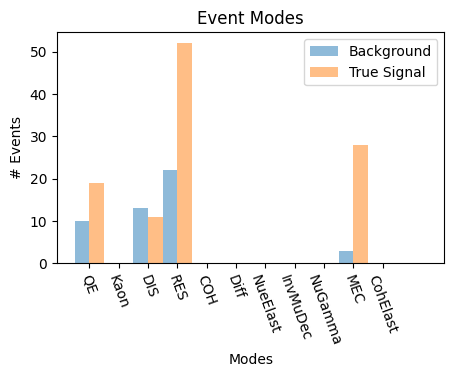

In [141]:
#Look at what type of events are background. Background = signal, not true
background_mode = []
true_signal_mode = []

for ev in range(len(mode_event)):
    if signal_event[ev] == 1 and true_event[ev] == 0:
        background_mode.append(mode_event[ev])
    elif signal_event[ev] == 1 and true_event[ev] == 1:
        true_signal_mode.append(mode_event[ev])

mec_perc = true_signal_mode.count(10)/len(true_signal_mode)
print("Percentage of true signal events that are MEC: ", mec_perc)

#Make a histogram of the background event modes
fig = plt.figure(figsize=(5,3))
n, bins, edges = plt.hist(background_mode, bins=np.arange(1.0, 13.0, 0.5), density=False, alpha=0.5, align='left')
n_ts, bins_ts, edges_ts = plt.hist(true_signal_mode, bins=np.arange(1.0, 13.0, 0.5), density=False, alpha=0.5, align='right')
plt.xticks(np.arange(1.25, 12.25, 1.0), ['QE', 'Kaon', 'DIS', 'RES', 'COH', 'Diff', 'NueElast', 'InvMuDec', 'NuGamma', 'MEC', 'CohElast'], rotation=290)
plt.xlabel("Modes")
plt.ylabel("# Events")
plt.title("Event Modes")
plt.legend(['Background', 'True Signal'])
plt.show()

## Significance

/tmp/ipykernel_518305/2523863152.py:2: RuntimeWarning: invalid value encountered in divide
  sig_lpp = np.array(signal_lpp)/(np.sqrt(np.array(signal_lpp) + np.array(background_lpp)))
/tmp/ipykernel_518305/2523863152.py:3: RuntimeWarning: invalid value encountered in divide
  sig_rpp = np.array(signal_rpp)/(np.sqrt(np.array(signal_rpp) + np.array(background_rpp)))
/tmp/ipykernel_518305/2523863152.py:4: RuntimeWarning: invalid value encountered in divide
  sig_mu = np.array(signal_mu)/(np.sqrt(np.array(signal_mu) + np.array(background_mu)))
/tmp/ipykernel_518305/2523863152.py:5: RuntimeWarning: invalid value encountered in divide
  sig_nu = np.array(signal_nu)/(np.sqrt(np.array(signal_nu) + np.array(background_nu)))


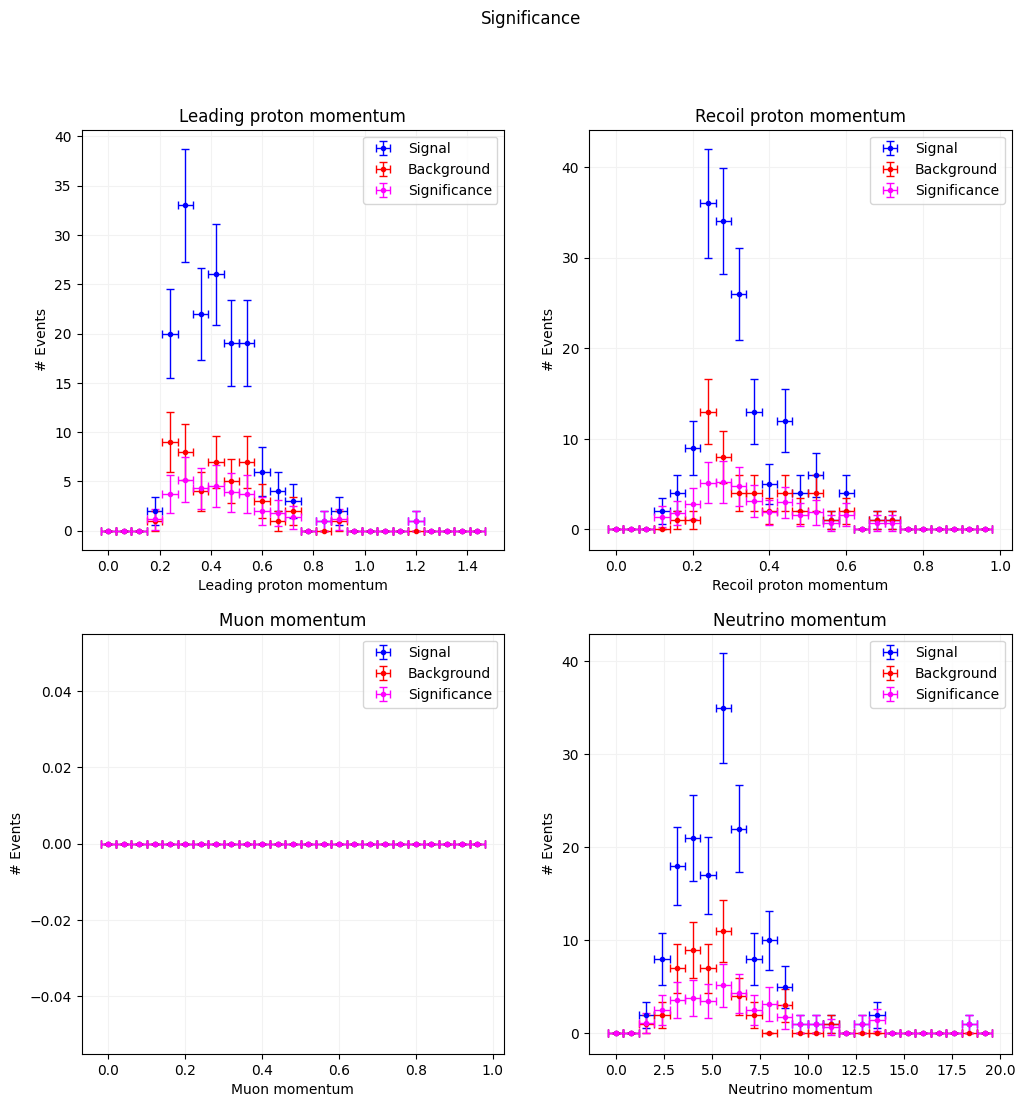

Leading proton momentum cutoff:  0.3
Recoil proton momentum cutoff:  0.28
Muon momentum cutoff:  0.0
Neutrino momentum cutoff:  5.6000000000000005


In [142]:
#Plot signal, background, and significance vs. proton momentum, muon momentum, and neutrino energy
sig_lpp = np.array(signal_lpp)/(np.sqrt(np.array(signal_lpp) + np.array(background_lpp)))
sig_rpp = np.array(signal_rpp)/(np.sqrt(np.array(signal_rpp) + np.array(background_rpp)))
sig_mu = np.array(signal_mu)/(np.sqrt(np.array(signal_mu) + np.array(background_mu)))
sig_nu = np.array(signal_nu)/(np.sqrt(np.array(signal_nu) + np.array(background_nu)))

np.nan_to_num(sig_lpp, False, nan=0.0, posinf=0.0, neginf=0.0)
np.nan_to_num(sig_rpp, False, nan=0.0, posinf=0.0, neginf=0.0)
np.nan_to_num(sig_mu, False, nan=0.0, posinf=0.0, neginf=0.0)
np.nan_to_num(sig_nu, False, nan=0.0, posinf=0.0, neginf=0.0)

#----------------Can use the same vertical error bars for this that I did for the purity and efficiency plots------------------------
#ax[1,0].errorbar(bin_centers_mu, eff_vals_mu, xerr=bin_width_mu/2, yerr=stat_error_mu, fmt='.', color='coral', label='Efficiency', elinewidth=2, capsize=3)

fig, ax = plt.subplots(2, 2, figsize=(12,12))
fig.suptitle('Significance')
#Leading Proton Momentum
#ax[0,0].plot(lpp_values, signal_lpp, color='blue', label='Signal')
#ax[0,0].plot(lpp_values, background_lpp, color='red', label='Background')
#ax[0,0].plot(lpp_values, sig_lpp, color='magenta', label='Significance')
ax[0,0].errorbar(lpp_values, signal_lpp, xerr=bin_width_lpp/2, yerr=(np.sqrt(signal_lpp)), fmt='.', color='blue', label='Signal', elinewidth=1, capsize=3)
ax[0,0].errorbar(lpp_values, background_lpp, xerr=bin_width_lpp/2, yerr=(np.sqrt(background_lpp)), fmt='.', color='red', label='Background', elinewidth=1, capsize=3)
ax[0,0].errorbar(lpp_values, sig_lpp, xerr=bin_width_lpp/2, yerr=(np.sqrt(sig_lpp)), fmt='.', color='magenta', label='Significance', elinewidth=1, capsize=3)
ax[0,0].set_xlabel('Leading proton momentum')
ax[0,0].set_ylabel('# Events')
ax[0,0].set_title('Leading proton momentum')
ax[0,0].legend()
ax[0,0].grid(color='0.95')
#Recoil Proton Momentum
ax[0,1].errorbar(rpp_values, signal_rpp, xerr=bin_width_rpp/2, yerr=(np.sqrt(signal_rpp)), fmt='.', color='blue', label='Signal', elinewidth=1, capsize=3)
ax[0,1].errorbar(rpp_values, background_rpp, xerr=bin_width_rpp/2, yerr=(np.sqrt(background_rpp)), fmt='.', color='red', label='Background', elinewidth=1, capsize=3)
ax[0,1].errorbar(rpp_values, sig_rpp, xerr=bin_width_rpp/2, yerr=(np.sqrt(sig_rpp)), fmt='.', color='magenta', label='Significance', elinewidth=1, capsize=3)
ax[0,1].set_xlabel('Recoil proton momentum')
ax[0,1].set_ylabel('# Events')
ax[0,1].set_title('Recoil proton momentum')
ax[0,1].legend()
ax[0,1].grid(color='0.95')
#Muon Momentum
ax[1,0].errorbar(mu_values, signal_mu, xerr=bin_width_mu/2, yerr=(np.sqrt(signal_mu)), fmt='.', color='blue', label='Signal', elinewidth=1, capsize=3)
ax[1,0].errorbar(mu_values, background_mu, xerr=bin_width_mu/2, yerr=(np.sqrt(background_mu)), fmt='.', color='red', label='Background', elinewidth=1, capsize=3)
ax[1,0].errorbar(mu_values, sig_mu, xerr=bin_width_mu/2, yerr=(np.sqrt(sig_mu)), fmt='.', color='magenta', label='Significance', elinewidth=1, capsize=3)
ax[1,0].set_xlabel('Muon momentum')
ax[1,0].set_ylabel('# Events')
ax[1,0].set_title('Muon momentum')
ax[1,0].legend()
ax[1,0].grid(color='0.95')
#Neutrino Momentum
ax[1,1].errorbar(nu_values, signal_nu, xerr=bin_width_nu/2, yerr=(np.sqrt(signal_nu)), fmt='.', color='blue', label='Signal', elinewidth=1, capsize=3)
ax[1,1].errorbar(nu_values, background_nu, xerr=bin_width_nu/2, yerr=(np.sqrt(background_nu)), fmt='.', color='red', label='Background', elinewidth=1, capsize=3)
ax[1,1].errorbar(nu_values, sig_nu, xerr=bin_width_nu/2, yerr=(np.sqrt(sig_nu)), fmt='.', color='magenta', label='Significance', elinewidth=1, capsize=3)
ax[1,1].set_xlabel('Neutrino momentum')
ax[1,1].set_ylabel('# Events')
ax[1,1].set_title('Neutrino momentum')
ax[1,1].legend()
ax[1,1].grid(color='0.95')

plt.show()

print("Leading proton momentum cutoff: ", lpp_values[np.nanargmax(sig_lpp)])
print("Recoil proton momentum cutoff: ", rpp_values[np.nanargmax(sig_rpp)])
print("Muon momentum cutoff: ", mu_values[np.nanargmax(sig_mu)])
print("Neutrino momentum cutoff: ", nu_values[np.nanargmax(sig_nu)])

## Proton Momentum truth vs. reco plots

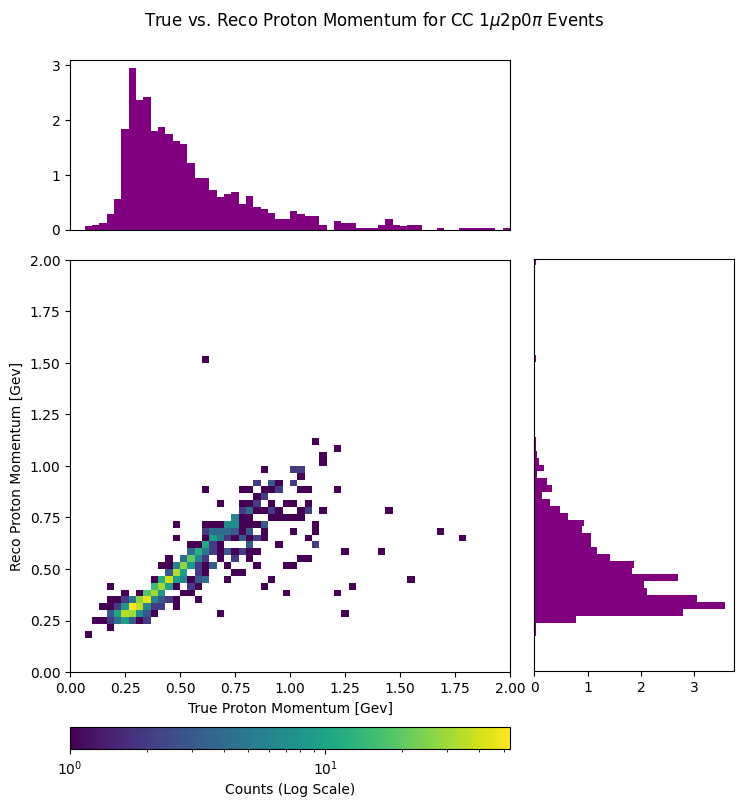

In [143]:
#2D histogram with 1D projections
fig = plt.figure(figsize=(8,10))
left, width, bottom, height = 0.12, 0.55, 0.12, 0.55
bottom_h = left_h = left + width + 0.03
#Dimensions
dim_2dhist = [left, bottom, width, height] #Dimensions of 2d hist
dim_1dhistx = [left, bottom_h, width, 0.17] #Dimensions of 1d x hist
dim_1dhisty = [left_h, bottom + 0.139, 0.25, height-0.138] #Dimensions of 1d y hist
#Make the plots
ax2dhist = plt.axes(dim_2dhist) #2d hist plot
ax1dhistx = plt.axes(dim_1dhistx) #1d x hist plot
ax1dhisty = plt.axes(dim_1dhisty) #1d y hist plot
#Plot histograms
_,_,_,im =ax2dhist.hist2d(hist_proton_truep, hist_proton_recop, bins=60, range=((0,2),(0,2)),norm=colors.LogNorm())
ax1dhistx.hist(true_proton_p, bins=60, range=(0,2), density=True, color='purple')
ax1dhisty.hist(reco_proton_p, bins=60, range=(0,2), density=True, orientation='horizontal', color='purple')
ax1dhistx.set_xlim(0,2)
ax1dhisty.set_ylim(0,2)
#Make it pretty
ax2dhist.set_xlabel("True Proton Momentum [Gev]")
ax2dhist.set_ylabel("Reco Proton Momentum [Gev]")
ax1dhistx.get_xaxis().set_visible(False)
ax1dhisty.get_yaxis().set_visible(False)
cbar = plt.colorbar(im, ax=ax2dhist, pad=0.1, location='bottom')
cbar.set_label('Counts (Log Scale)')
plt.suptitle("True vs. Reco Proton Momentum for CC 1$\mu$2p0$\pi$ Events", y=0.92)
plt.show()


## Accuracy of proton ID by momenta confusion matrix

{-211: 'π-', -13: 'μ+', -11: 'e+', 11: 'e-', 13: 'μ-', 22: 'γ', 211: 'π+', 321: 'K+', 2112: 'n', 2212: 'p', 3122: 'Σ', 4212: 'D'}


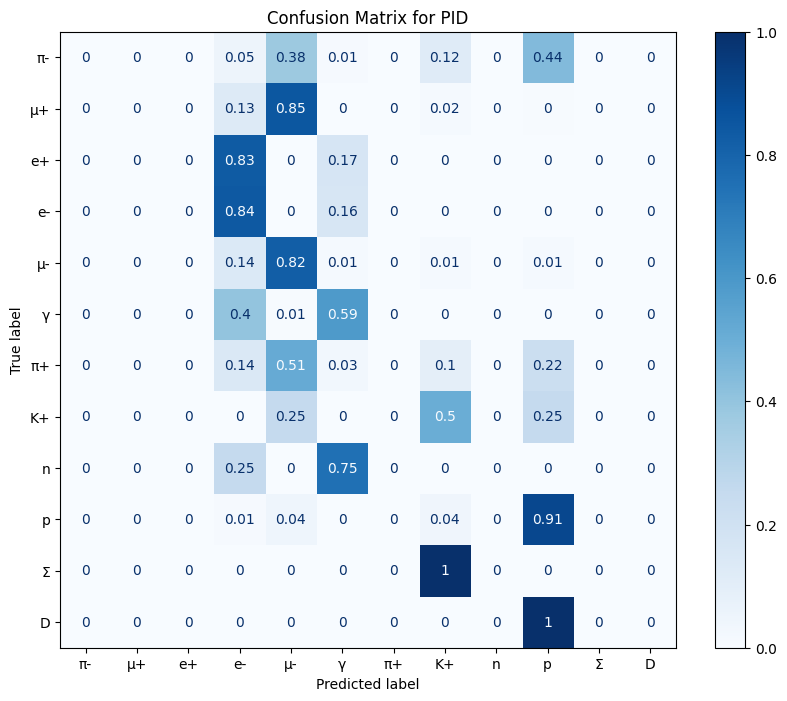

In [164]:
#https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html
fig, ax = plt.subplots(figsize=(10, 8))
#Change this to be not just "not proton", but to include what the proton is being identified as (muon, pion, etc.). 
#Do this for every particle type
data_pid = {'true_pid': true_pid, 'reco_pid': reco_pid}
df_pid = pd.DataFrame(data=data_pid)
labels_pid = {-211: "\u03c0-", -13: "\u03bc+", -11: "e+", 11: "e-", 13: "\u03bc-", 22: "\u03B3", 211: "\u03c0+", 321: "K+", 2112: "n", 2212: "p", 3122: "\u03A3", 4212: "D"}
print(labels_pid)

cm = confusion_matrix(true_pid, reco_pid, normalize="true")
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_pid.values())
disp.plot(ax=ax,cmap=plt.cm.Blues, values_format='.2f')

# This converts things like 0.0 to 0, 1.0 to 1, and limits floats to 2 decimal places max
for text in disp.text_.ravel():
    val = float(text.get_text())
    if val == 0:
        text.set_text("0")
    elif val == 1:
        text.set_text("1")
    else:
        # Removes trailing zeros if the number rounds nicely (e.g., 0.80 becomes 0.8)
        text.set_text(f"{val:.2f}".rstrip('0').rstrip('.'))

plt.title('Confusion Matrix for PID')
plt.show()

## Purity and Efficiency vs. Cuts 

Scatter plot showing the progression of the purity and efficiency as each subsequent cut is added

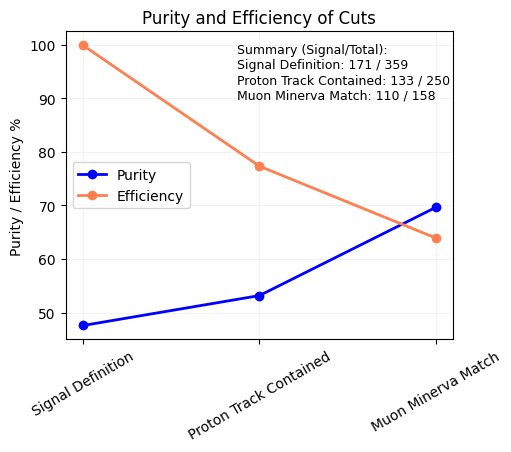

In [145]:
#Not using the cuts with momentum, those dropped the purity compared to the minerva matching
#Cut 1: vertex within volume, Np=2, Nmu=1, Npi=0
#Cut 2: Proton track fully contained
#Cut 3: Muon track punches out the back of minerva
purity_cuts = [47.63, 53.20, 69.62]
efficiency_cuts = [99.82, 77.32, 63.95]
phase = ['Signal Definition', 'Proton Track Contained', 'Muon Minerva Match']
phase_num = [1, 2, 3]

plt.figure(figsize=(5,4))
plt.plot(phase_num, purity_cuts, marker='o', label='Purity', linewidth=2, color='blue')
plt.plot(phase_num, efficiency_cuts, marker='o', label='Efficiency', linewidth=2, color='coral')
plt.xticks(phase_num, phase, rotation=30)
plt.ylabel('Purity / Efficiency %')
plt.title('Purity and Efficiency of Cuts')
plt.grid(color='0.95')
plt.legend(loc='center left')
plt.text(1.87, 90, "Summary (Signal/Total): \nSignal Definition: 171 / 359 \nProton Track Contained: 133 / 250 \n" \
"Muon Minerva Match: 110 / 158", color='black', fontsize=9)
plt.show()

#171 signal events cut 1
#133 signal events cut 2
#110 signal events cut 4

## Angle between protons histogram

Histogram displaying the number of events for each bin of angle between proton momenta. Bins are 0.05 wide, plotting the cosine of the angle between the leading and recoil proton.

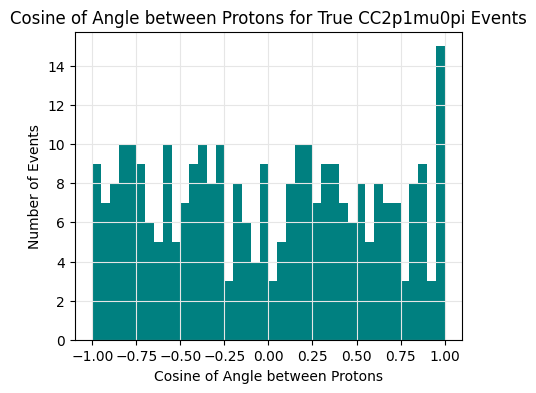

9


In [146]:
#theta_pp histogram
plt.figure(figsize=(5,4))
plt.hist(theta_pp, bins=40, range=(-1,1), color='teal')
plt.xlabel('Cosine of Angle between Protons')
plt.ylabel('Number of Events')
plt.title('Cosine of Angle between Protons for True CC2p1mu0pi Events')
plt.grid(color='0.9')
#plt.legend(loc='upper right')
plt.show()

count = sum(1 for x in theta_pp if x <= -0.95)
print(count)